**Load environmental variables**: See "Getting setup" in the first modele.  `dotenv` [docs](https://pypi.org/project/python-dotenv/) will look for `../.env`. If it finds it, it will load environmental variables from there, overriding any variables in the current shell. If it is not found, variables currently in the shell are used.

In [1]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="LangSmith now uses UUID v7", 
    category=UserWarning,
)

In [2]:
import os

from dotenv import load_dotenv

load_dotenv("../../.env")

# # automatically reload all modules before executing new code. The captures changes in local packages.
# %load_ext autoreload
# %autoreload 2

True

## Create Agent  - Prebuilt

<img src="./assets/agent_header.png" width="800" style="display:block; margin-left:0;">

이 강좌에서는 [Deep Agent](https://blog.langchain.com/deep-agents/)를 직접 만들어 보게 됩니다. 
코드를 상당히 간소화해 주는 LangChains의 ‘사전 구축된’ 에이전트 추상화 구조를 기반으로 이를 구현할 것입니다. 
이번 강의에서는 사전 구축된 ReAct 에이전트에 대해 알아보겠습니다. 
학습 내용은 다음과 같습니다:
- ReAct 에이전트란 무엇인가
- 구현의 기능 및 추가 정보 확인 방법
    - 도구를 사용하여 에이전트 구축하기
    - 그래프, 상태 및 메시지
    - 도구를 사용하여 상태에 접근하고 수정하기
    - <span style="font-size:0.8em;">🪝</span> 훅! 및 구조화된 응답


### What is a ReAct agent 


<img src="./assets/agent.png"
     style="float:left; max-width:300px; height:auto; margin:0 1rem 0.5rem 0;">
<div style="max-width: 1250px;">
    
LangChain의 오픈소스 `create_agent` ([여기 참조](https://docs.langchain.com/oss/python/langchain/agents)) 추상화 함수 사용하게 됩니다.   
**ReAct 에이전트**는 “추론 및 행동(Reasoning and Acting, ReAct)” 프레임워크를 사용하여 사고의 연쇄(CoT) 추론과 외부 도구 사용을 결합한 AI 에이전트입니다.    
이 에이전트는 [ReAct: Synergizing Reasoning and Acting in Language Models](https://arxiv.org/abs/2210.03629) 논문을 통해 널리 알려졌습니다. 

이 에이전트는 대규모 언어 모델(LLM), 사용할 수 있는 도구 세트, 지침을 제공하는 프롬프트의 세 가지 구성 요소로 이루어져 있습니다.

LLM은 루프 방식으로 작동합니다. 각 반복 단계에서, 사용 가능한 도구 목록을 포함한 컨텍스트를 검토하고, 도구를 호출해야 할지 여부를 결정합니다.    
호출할 도구를 선택하고, 도구 호출 명령을 생성합니다.    
이 명령은 실행을 위해 도구 노드로 전송됩니다. 도구 노드는 도구를 실행하고, 그 결과(관측값)를 LLM으로 다시 전송합니다.    
LLM은 관측값을 수신하고, 이를 바탕으로 다음 행동을 결정합니다.    
이 루프는 중지 조건이 충족될 때까지 계속되며, 일반적으로 에이전트가 더 이상 도구를 호출할 필요가 없다고 판단할 때 종료됩니다.
</div>

<div style="clear:both;"></div>


### `create_agent`의 주요 기능

다음은 `create_agent` 추상화 구조가 제공하는 몇 가지 기능입니다.   
이 강좌에서는 이 모든 기능을 활용하지는 않겠지만, 강좌를 구성하는 데 `create_agent`를 사용해야 하는 이유를 잘 보여줍니다.:

- [메모리 통합](../how-tos/memory/add-memory.md): _단기_ (세션 기반) 및 _장기_ (세션 간 지속) 메모리에 대한 네이티브 지원을 통해 챗봇과 어시스턴트에서 상태 유지 기능을 구현할 수 있습니다.
- [Human-in-the-loop 제어](../concepts/human_in_the_loop.md): 웹소켓 기반 솔루션이 실시간 상호작용으로 제한되는 것과는 달리, 실행을 _무기한_ 일시 중지하여 사람의 피드백을 기다릴 수 있습니다. 이를 통해 워크플로우의 어느 단계에서든 비동기적인 승인, 수정 또는 개입이 가능합니다.
- [스트리밍 지원](../how-tos/streaming.md): 에이전트 상태, 모델 토큰, 도구 출력 또는 결합된 스트림의 실시간 스트리밍.
- [배포 도구](../tutorials/langgraph-platform/local-server.md): 인프라가 필요 없는 배포 도구를 포함합니다. [**LangGraph Platform**](https://langchain-ai.github.io/langgraph/concepts/langgraph_platform/)은 테스트, 디버깅 및 배포를 지원합니다.
  - [Studio](https://langchain-ai.github.io/langgraph/concepts/langgraph_studio/): 워크플로우를 검사하고 디버깅하기 위한 시각적 IDE입니다.
  - [LangSmith](https://smith.langchain.com/): 추적 및 평가 도구입니다.
  - 프로덕션 환경을 위한 다양한 [배포 옵션](https://langchain-ai.github.io/langgraph/concepts/deployment_options.md)을 지원합니다.

Translated with DeepL.com (free version)

  

<div style="background-color: #fff3b0; padding: 10px; border-radius: 4px;">
<b>Note:</b>  
The <code>create_react_agent</code> was moved from the LangGraph library to the LangChain library and renamed to <code>create_agent</code> in the 1.0 code release post-filming. The video and notebooks in this lesson have been updated to reflect this; however, in the remaining lessons, only the notebooks are updated.

#### 도구를 활용한 에이전트 구축

우선 간단한 계산기 도구를 갖춘 에이전트를 만들어 보겠습니다. 전체적인 구조를 파악한 후, 더 자세한 내용을 살펴보겠습니다.

In [3]:
from typing import Annotated, List, Literal, Union

from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command


@tool
def calculator(
    operation: Literal["add","subtract","multiply","divide"],
    a: Union[int, float],
    b: Union[int, float],
) -> Union[int, float]:
    """정확한 답을 반환하는 2개 입력용 계산기 도구를 정의

    Arg:
        operation (str): 실행할 연산 ('add', 'subtract', 'multiply', 'divide').
        a (float or int): 첫번째 숫자.
        b (float or int): 두번째 숫자.
        
    Returns:
        result (float or int): 연산결과
    Example
        Divide: result   = a / b
        Subtract: result = a - b
    """
    if operation == 'divide' and b == 0:
        return {"error": "Division by zero is not allowed."}

    # Perform calculation
    if operation == 'add':
        result = a + b
    elif operation == 'subtract':
        result = a - b
    elif operation == 'multiply':
        result = a * b
    elif operation == 'divide':
        result = a / b
    else: 
        result = "unknown operation"
    return result


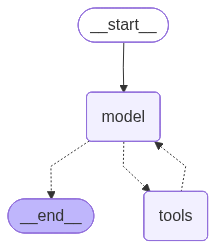

In [4]:
from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langchain.agents import create_agent 
from utils import format_messages

# Create agent using create_agent directly
SYSTEM_PROMPT = """
당신은 계산기 사용에 능숙한 유능한 산술 연산 전문가입니다.
모든 결과를 마크다운 math delimiters 없이 일반 텍스트로 반환하십시오.
"""

model = init_chat_model(model="anthropic:claude-sonnet-4-6", temperature=0.0)
tools = [calculator]

# Create agent
agent = create_agent(             # updated for 1.0
    model,
    tools,
    system_prompt=SYSTEM_PROMPT,  # updated for 1.0
    #state_schema=AgentState,  # default
).with_config({"recursion_limit": 20})  #recursion_limit limits the number of steps the agent will run

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [5]:
# create_react_agent returns a compiled graph
type(agent)

langgraph.graph.state.CompiledStateGraph

###  The graph, state and messages
잠시 후 에이전트를 실행하게 되겠지만, 먼저 그래프에 대해 조금 더 자세히 알아보겠습니다. 
 이 내용을 직접 간단하게 구현해 보고 싶으시다면, [Foundation: LangGraph 소개, 모듈 1, 레슨 6, 에이전트](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239232-lesson-6-agent)를 확인해 보세요.

**에이전트 정의**: 위와 같이 에이전트를 정의할 때는 모델, 하나 이상의 도구, “시스템” 프롬프트, 그리고 기본적으로 <a href="https://github.com/langchain-ai/langgraph/blob/ e365b2b8bd695e03d758b19ff109152b2e342a87/libs/prebuilt/langgraph/prebuilt/chat_agent_executor.py#L62-L69">
  <code style="color:#0366d6;">AgentState</code>
</a>이며, 이는 주로 메시지 목록으로 구성됩니다. ([자세한 내용은 여기에서 확인하세요.](https://langchain-ai.github.io/langgraph/reference/agents/#langgraph.prebuilt.chat_agent_executor.create_react_agent))
내부적으로는 위에서 보여준 LangGraph 그래프를 정의하고 컴파일하는 과정입니다. 중요한 점은 tools 노드가 또 다른 사전 구축된 항목인 `ToolNode`이며, 이에 대한 설명은 [여기](https://github.com/langchain-ai/langgraph/blob/e365b2b8bd695e03d758b19ff109152b2e342a87/libs/prebuilt/langgraph/prebuilt/tool_node.py#L239-L293)에서 설명된 `ToolNode`라는 또 다른 사전 구축된 항목입니다. 툴 노드는 LLM에서 전송된 메시지에 명시된 모든 도구를 실행하고 그 결과를 반환합니다.

**에이전트 호출:** 
이제 에이전트를 호출하여 어떤 결과가 나오는지 확인해 봅시다!

Translated with DeepL.com (free version)

In [6]:
# Example usage
result1 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "3.1 * 4.2는 얼마야?",
            }
        ],
    }
)

format_messages(result1["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ 3.1 * 4.2는 얼마야?                                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 3.1 곱하기 4.2를 계산해 드리겠습니다!                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: calculator                                                                                        │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 3.1,                                                                                                     │
│   "b": 4.2                                                                                                      │
│ }                                                                                                               │
│    ID: toolu_01Wbrriv8wWNTmdfWj5Bnexf                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 13.020000000000001                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 3.1 × 4.2 = 13.02 입니다! 😊                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

**Invoking the Agent:** 
시퀀스 다이어그램은 모델이 호출될 때 어떤 일이 일어나는지 파악하는 데 매우 유용한 방법입니다.

<div style="display:none">
    the mermaid code is saved here for future
```mermaid
sequenceDiagram
    participant U as User
    participant A as LLM
    participant T as Tools
    Note over A: System message<br/>"You are a helpful assistant..."
    U->>A: Initial input,<br/>"What is 3.1 * 4.2?"
    loop while tool_calls present
        A->>T: AIMessage(id="call_123", tool_calls=[...])
        T-->>A: ToolMessage(tool_call_id="call_123", content="xx")
    end
    A->>U: Return final state
```
</div> 

<img src="./assets/agent_sequence_diagram.png"
     style="float:left; max-width:500px; height:auto; margin:0 1rem 0.5rem 0;">
<div style="max-width: 1100px;">
이 예시에서 사용자의 입력은 “3.1 × 4.2는 얼마인가요?”입니다. 이 입력은 시스템 프롬프트 및 도구 설명과 함께 LLM으로 전송됩니다.  
<br/>
<p style="margin-bottom:0; margin-top:5px;">LLM은 계산기 도구를 호출해야 한다고 결정합니다.<br/> `messages`에 `AIMessage`를 추가합니다:</p>
<pre style="font-size:0.85em; margin-top:5px; margin-bottom:0;">
<code class="language-python">AIMessage(
    content="",
    tool_calls=[{"id": "call_123",
                 "name": "calculator",
                 "args": {"a": 3.1, "b": 4.2, "operation": "multiply"}}])</code></pre>   
</code></pre>
<br/>
<p style="margin-bottom:0;">도구 노드는 AIMessage를 수신하고 모든 도구 호출을 처리합니다. 이 노드는 tool_call_ids를 추적합니다. 그리고 `messages`에 ToolMessage를 포함하여 응답합니다: </p>
<pre style="font-size:0.85em; margin-top:5px; margin-bottom:10px;">
<code class="language-python">ToolMessage(
    content="13.02",         # The result of the tool execution.
    tool_call_id="call_123")  # Matches the id from the AIMessage.tool_calls
</code></pre>
LLM은 `messages`에 있는 응답을 검토한 후, 처리가 완료되었다고 판단하고 사용자에게 보낼 `AIMessage`를 생성합니다.

</div>

<div style="clear:both;"></div>

#### Try your own
Take a moment and try this on your own. Run a query, check your own trace in LangSmith and see if it matches your expectation. Try expanding the calculator - maybe add a square function.

Let's look at a prior [trace in LangSmith](https://smith.langchain.com/public/3d2062e3-8713-4510-a797-801abe44d1f7/r). Here are some things to notice:
- In the metadata of the call to the LLM, you will see the 'calculator' tool description.
- The response from the model is a tool call with the arguments
- In the final call to the LLM, notice the matching tool_call_id's provided by the tool node.

In [ ]:
# Try your own 
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is ...?",
            }
        ],
    }
)

format_messages(result["messages"])

### Access and modify state within tools
#### State
LangGraph의 훌륭한 기능 중 하나는 ‘상태(state)’입니다. 그래프에는 그래프가 실행되는 동안 각 노드에서 사용할 수 있고 장기 저장소에 영구적으로 저장할 수 있는 타입 지정 데이터 구조가 있습니다. 이를 활용하여 노드 간에 공유할 정보를 저장하거나, 그래프를 디버깅하거나, 장시간 실행 중인 그래프를 이전 시점으로 되돌릴 수 있습니다.

그래프의 상태를 정의할 때는 데이터 유형과 ‘리듀서(reducer)’ 함수를 지정합니다. 리듀서는 해당 요소에 정보가 어떻게 추가되는지를 설명합니다. 이는 작업이 여러 노드에 매핑되어 병렬로 실행되고, 각 노드가 동시에 상태를 업데이트할 때 특히 유용합니다.

이 예제에서는 기본 `AgentState`가 사용되었습니다. 이는 [langgraph.prebuilt. chat_agent_executor](https://github.com/langchain-ai/langgraph/blob/e365b2b8bd695e03d758b19ff109152b2e342a87/libs/prebuilt/langgraph/prebuilt/chat_agent_executor.py)에 정의되어 있습니다.   

```python
    class AgentState(TypedDict):
        """The state of the agent."""
        messages: Annotated[Sequence[BaseMessage], add_messages]
        remaining_steps: NotRequired[RemainingSteps]
```
        
- `messages`는 `BaseMessage`의 리스트이며, 이는 [langchain_core](https://github.com/langchain-ai/langchain/blob/088095b663993b1e53cf616e1ca487d1739b0d71/libs/core/langchain_core/messages/base.py)에 정의되어 있으며, LLM과의 송수신 메시지를 포함합니다.
    - `typing.Annotated`를 사용하면 타입 힌트에 임의의 메타데이터를 첨부할 수 있습니다. 구문: `Annotated[Type, metadata1, metadata2, ...]` 
- `add_messages` 리듀서는 메시지 목록의 끝에 새로운 메시지를 추가합니다.  
- `remaining_steps`는 그래프 내의 단계를 추적합니다. 이 변수는 `recursion_limit`으로 초기화되어 있지만, 그래프에 의해 추적되며 사용자에게는 표시되지 않습니다.  
이 내용을 간단히 살펴보겠습니다.

In [7]:
from IPython.display import JSON
from langchain_core.messages import messages_to_dict

JSON({"messages": messages_to_dict(result1["messages"])})

<IPython.core.display.JSON object>

#### Custom State
계산기를 확장하여 지금까지 수행된 모든 연산 리스트 저장하도록 합시다. 
이를 위해서는 state에 list를 추가하고, state를 list에 추가하는 리듀서 함수를 구현해야 합니다. 이렇게 하면 리스트나 연산이 비어 있는 경우를 안전하게 처리할 수 있습니다.

In [8]:
#from langgraph.prebuilt.chat_agent_executor import AgentState
from langchain.agents import AgentState  # updated in 1.0


def reduce_list(left: list | None, right: list | None) -> list:
    """Safely combine two lists, handling cases where either or both inputs might be None.

    Args:
        left (list | None): The first list to combine, or None.
        right (list | None): The second list to combine, or None.

    Returns:
        list: A new list containing all elements from both input lists.
               If an input is None, it's treated as an empty list.
    """
    if not left:
        left = []
    if not right:
        right = []
    return left + right

class CalcState(AgentState):
    """Graph State."""
    ops: Annotated[List[str], reduce_list]


#### Accessing State 
이제 계산기에 이 업데이트를 반영하도록 확장할 수 있습니다. 여기서 한 가지 문제가 드러납니다! 이제 ‘state’가 계산기 도구의 인수가 되었습니다. 
<img src="./assets/state_arg_diagram.png" width="800" style="display:block; margin-left:0;">
도표에서 볼 수 있듯이, LLM은 도구 호출을 생성하는 역할을 맡고 있지만, 컨텍스트에 `state` 인수가 포함되어 있지 않아 이를 구성할 수 없습니다!  
해결책은 LLM 처리 후 **상태를 주입**하는 것입니다.
<img src="./assets/inject_state_diagram.png" width="1000" style="display:block; margin-left:0;"> 

<div style="margin:0; padding:0">
  <p style="margin:0;">This is accomplished with the <code>InjectedState</code> annotation as shown below.</p>
  <pre style="font-size:0.90em; margin:0; padding-top:0;">
<code class="language-python">    @tool
    def calculator_wstate(
        operation: Literal["add","subtract","multiply","divide"],
        a: Union[int, float],
        b: Union[int, float],
        <span style="background:#fff3a3; padding:0 2px;">state: Annotated[CalcState, InjectedState],</span>  # ← not sent to LLM
        <span style="background:#fff3a3; padding:0 2px;">tool_call_id: Annotated[str, InjectedToolCallId],</span>  # ← not sent to LLM
    ) -> Union[int, float]:
</code></pre>
<p style="margin:0; padding-top:4px;">
    이 코드는 LLM에 제공된 설명에서 <code>state</code>를 제거하고, <code>ToolNode</code>에서 도구를 호출할 때 이를 주입합니다. <code>tool_call_id</code>도 포함됩니다. 이에 대한 설명은 다음 섹션에서 다룹니다.
  </p>
</div>

#### Updating State
도구는 일반적으로 관측 결과를 `messages` 필드에 포함된 `ToolMessage` 형태로 LLM에 반환한다는 점을 기억하실 겁니다. 상태(state)의 다른 멤버를 업데이트하려면 이 업데이트를 확장해야 합니다. 이는 아래 반환 예시에서 볼 수 있듯이 `Command`를 사용하여 수행됩니다. 
```python
    return Command(
        update={
            "ops": ops,
            "messages": [
                ToolMessage(f"{result}", tool_call_id=tool_call_id)
            ]})
```
Note that to create a `ToolMessage` we needed the `tool_call_id`.

In [9]:
@tool
def calculator_wstate(
    operation: Literal["add","subtract","multiply","divide"],
    a: Union[int, float],
    b: Union[int, float],
    state: Annotated[CalcState, InjectedState],   # not sent to LLM
    tool_call_id: Annotated[str, InjectedToolCallId] # not sent to LLM
) -> Union[int, float]:
    """Define a two-input calculator tool.

    Arg:
        operation (str): The operation to perform ('add', 'subtract', 'multiply', 'divide').
        a (float or int): The first number.
        b (float or int): The second number.
        
    Returns:
        result (float or int): the result of the operation
    Example
        Divide: result   = a / b
        Subtract: result = a - b
    """
    if operation == 'divide' and b == 0:
        return {"error": "Division by zero is not allowed."}

    # Perform calculation
    if operation == 'add':
        result = a + b
    elif operation == 'subtract':
        result = a - b
    elif operation == 'multiply':
        result = a * b
    elif operation == 'divide':
        result = a / b
    else: 
        result = "unknown operation"
    ops = [f"({operation}, {a}, {b})," ]
    return Command(
        update={
            "ops": ops,
            "messages": [
                ToolMessage(f"{result}", tool_call_id=tool_call_id)
            ],
        }
    )



In [10]:
SYSTEM_PROMPT = """
당신은 계산기 사용에 능숙한 유능한 산술 연산 전문가입니다.
모든 결과를 마크다운 math delimiters 없이 일반 텍스트로 반환하십시오.
"""

model = init_chat_model(model="anthropic:claude-sonnet-4-6", temperature=0.0)
tools = [calculator_wstate]  # new tool

# Create agent
agent = create_agent(
    model,
    tools,
    system_prompt=SYSTEM_PROMPT,
    state_schema=CalcState,  # now defining state scheme
).with_config({"recursion_limit": 20})  #recursion_limit limits the number of steps the agent will run

In [11]:
# Example usage
result2 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "3.1 * 4.2는 얼마야?",
            }
        ],
    }
)

format_messages(result2["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ 3.1 * 4.2는 얼마야?                                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 3.1 * 4.2를 계산해 드리겠습니다!                                                                                │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 3.1,                                                                                                     │
│   "b": 4.2                                                                                                      │
│ }                                                                                                               │
│    ID: toolu_01ELdsEGMbT4MaQWg4qZCK5s                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 13.020000000000001                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 3.1 × 4.2 = **13.02** 입니다! 😊                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [12]:
# notice the ops field is now in the response
JSON(result2)

<IPython.core.display.JSON object>

Let's try one more example. Notice the dual tool call in this example. The tool node will execute these in parallel.

In [13]:
# Example usage
result3 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "3.1 * 4.2 + 5.5 * 6.5는 얼마야?",
            }
        ],
    }
)

format_messages(result3["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ 3.1 * 4.2 + 5.5 * 6.5는 얼마야?                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 3.1 * 4.2와 5.5 * 6.5를 동시에 계산한 후, 두 결과를 더하겠습니다!                                               │
│                                                                                                                 │
│ **1단계: 두 곱셈을 동시에 계산**                                                                                │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 3.1,                                                                                                     │
│   "b": 4.2                                                                                                      │
│ }                                                                                                               │
│    ID: toolu_01AJBL2atQ9jniAwT4RVZN5t                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 5.5,                                                                                                     │
│   "b": 6.5                                                                                                      │
│ }                                                                                                               │
│    ID: toolu_01Jfykr2MV1ybCjjguhD2w8D                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 13.020000000000001                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 35.75                                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ - 3.1 * 4.2 = 13.02                                                                                             │
│ - 5.5 * 6.5 = 35.75                                                                                             │
│                                                                                                                 │
│ **2단계: 두 결과를 더하기**                                                                                     │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "add",                                                                                           │
│   "a": 13.02,                                                                                                   │
│   "b": 35.75                                                                                                    │
│ }                                                                                                               │
│    ID: toolu_012uxJx4yxJGptdsnPrHTAhY                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 48.769999999999996                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ ---                                                                                                             │
│                                                                                                                 │
│ 최종 결과는 다음과 같습니다:                                                                                    │
│                                                                                                                 │
│ 3.1 * 4.2 + 5.5 * 6.5 = 13.02 + 35.75 = **48.77**                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [14]:
JSON(result3)

<IPython.core.display.JSON object>

In [15]:
# Example usage - create your own
result4 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "예시를 만즐어줄래?",
            }
        ],
    }
)

format_messages(result4["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ 예시를 만즐어줄래?                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 물론입니다! 계산기를 사용한 간단한 예시들을 보여드릴게요. 4가지 연산을 동시에 계산해 드리겠습니다!              │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "add",                                                                                           │
│   "a": 25,                                                                                                      │
│   "b": 17                                                                                                       │
│ }                                                                                                               │
│    ID: toolu_019WeYGhwq7SAjAnu3zbcryU                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "subtract",                                                                                      │
│   "a": 100,                                                                                                     │
│   "b": 43                                                                                                       │
│ }                                                                                                               │
│    ID: toolu_01CwifQj3qSLscTDAKrMYd63                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 6,                                                                                                       │
│   "b": 8                                                                                                        │
│ }                                                                                                               │
│    ID: toolu_01B8o4HQ7JtGSVnHjuirTYbS                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "divide",                                                                                        │
│   "a": 90,                                                                                                      │
│   "b": 4                                                                                                        │
│ }                                                                                                               │
│    ID: toolu_01TaqVf2GcoMewd4wp535EKZ                                                                           │
╰──────────────────────────────────────────────────────────────────────────────────────────────────────

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 42                                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 57                                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 48                                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 22.5                                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 아래는 4가지 기본 연산 예시입니다:                                                                              │
│                                                                                                                 │
│ | 연산 | 식 | 결과 |                                                                                            │
│ |------|-----|------|                                                                                           │
│ | 덧셈 (add) | 25 + 17 | 42 |                                                                                   │
│ | 뺄셈 (subtract) | 100 - 43 | 57 |                                                                             │
│ | 곱셈 (multiply) | 6 x 8 | 48 |                                                                                │
│ | 나눗셈 (divide) | 90 / 4 | 22.5 |                                                                             │
│                                                                                                                 │
│ 원하시는 계산이 있으시면 언제든지 말씀해 주세요! 😊                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯